# LAB 1: Program to convert colorful image to grayscale

Image loaded! Shape: (538, 517, 3)


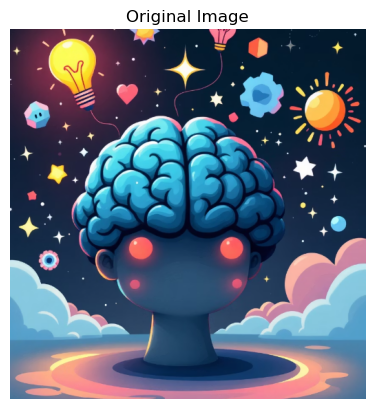

In [1]:
import cv2
import matplotlib.pyplot as plt

# Step 1: Read image directly by path (should be in same folder as ipynb)
image_path = "IPPR_IMG.jpg"   
bgr_image = cv2.imread(image_path)

# Step 2: Verify it loaded
if bgr_image is None:
    print("Image not loaded! Check the filename or path.")
else:
    print("Image loaded! Shape:", bgr_image.shape)

    # Step 3: Convert & Display 
    rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)
    plt.imshow(rgb_image)
    plt.axis('off')
    plt.title("Original Image")
    plt.show()

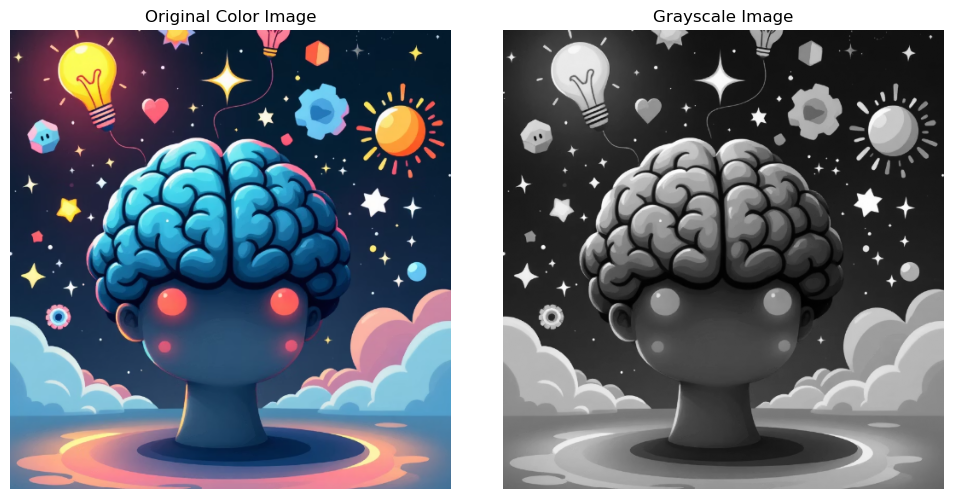

Color Image Shape  : (538, 517, 3)
Grayscale Image Shape: (538, 517)
Data Type          : uint8


In [2]:
# Convert BGR → Grayscale
gray_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2GRAY)

# Display Original vs Grayscale
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(rgb_image)
plt.title("Original Color Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(gray_image, cmap='gray')
plt.title("Grayscale Image")
plt.axis('off')

plt.tight_layout()
plt.show()

# Print Image Info
print("Color Image Shape  :", rgb_image.shape)    # (H, W, 3)
print("Grayscale Image Shape:", gray_image.shape)  # (H, W)
print("Data Type          :", gray_image.dtype)    # uint8

In [3]:
# Save to same folder as notebook
cv2.imwrite("gray_output.jpg", gray_image)
print("Saved as gray_output.jpg")

Saved as gray_output.jpg


Otsu's Auto Threshold Value: 105.0


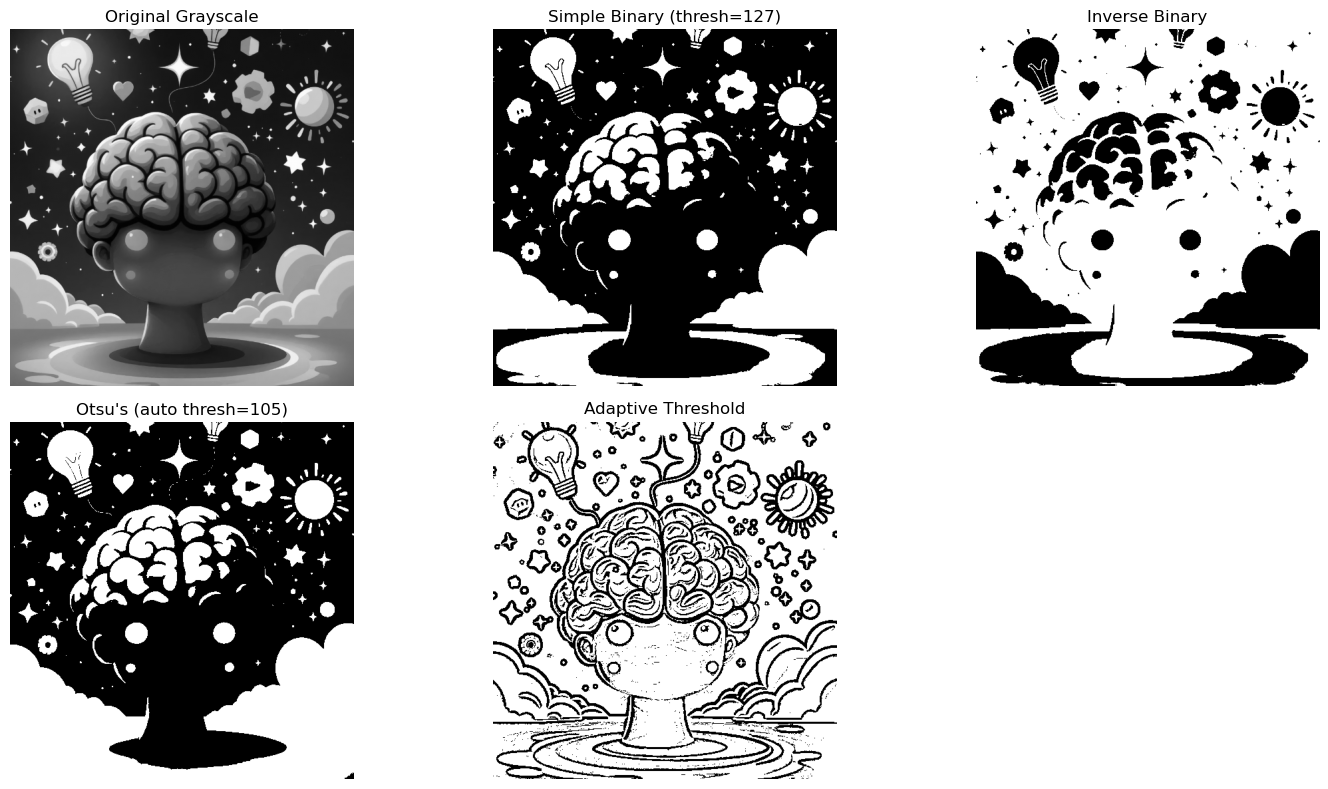

In [4]:
# GRAYSCALE TO BINARY IMAGE

# Method 1: Simple Binary Threshold
# pixels > 127 → 255 (white), pixels <= 127 → 0 (black)
_, binary_simple = cv2.threshold(gray_image, 127, 255, cv2.THRESH_BINARY)

# Method 2: Inverse Binary Threshold
# opposite of above — foreground becomes black
_, binary_inv = cv2.threshold(gray_image, 127, 255, cv2.THRESH_BINARY_INV)

# Method 3: Otsu's Threshold (Auto)
# automatically finds best threshold value
otsu_val, binary_otsu = cv2.threshold(gray_image, 0, 255,
                                       cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print("Otsu's Auto Threshold Value:", otsu_val)

# Method 4: Adaptive Threshold
# calculates threshold for small regions individually
binary_adaptive = cv2.adaptiveThreshold(gray_image, 255,
                                         cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                         cv2.THRESH_BINARY, 11, 2)

# Display All
plt.figure(figsize=(15, 8))

plt.subplot(2, 3, 1)
plt.imshow(gray_image, cmap='gray')
plt.title("Original Grayscale")
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(binary_simple, cmap='gray')
plt.title("Simple Binary (thresh=127)")
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(binary_inv, cmap='gray')
plt.title("Inverse Binary")
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(binary_otsu, cmap='gray')
plt.title(f"Otsu's (auto thresh={int(otsu_val)})")
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(binary_adaptive, cmap='gray')
plt.title("Adaptive Threshold")
plt.axis('off')

plt.tight_layout()
plt.show()